importing the libraries

In [30]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost
from xgboost import XGBRegressor
from sklearn import metrics

importing the dataset

In [3]:
df = pd.read_csv("BostonHousing.csv")

In [4]:
df.sample(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
485,3.67367,0.0,18.10,0,0.583,6.312,51.9,3.9917,24,666,20.2,388.62,10.58,21.2
71,0.15876,0.0,10.81,0,0.413,5.961,17.5,5.2873,4,305,19.2,376.94,9.88,21.7
186,0.05602,0.0,2.46,0,0.488,7.831,53.6,3.1992,3,193,17.8,392.63,4.45,50.0
359,4.26131,0.0,18.10,0,0.770,6.112,81.3,2.5091,24,666,20.2,390.74,12.67,22.6
139,0.54452,0.0,21.89,0,0.624,6.151,97.9,1.6687,4,437,21.2,396.90,18.46,17.8


feature scaling the data 

In [6]:
df.shape

(506, 14)

In [8]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

EXPLORATORY DATA ANALYSIS on the dataset

Understanding the correlation between the columns of our dataset

In [10]:
correlation = df.corr()

<Axes: >

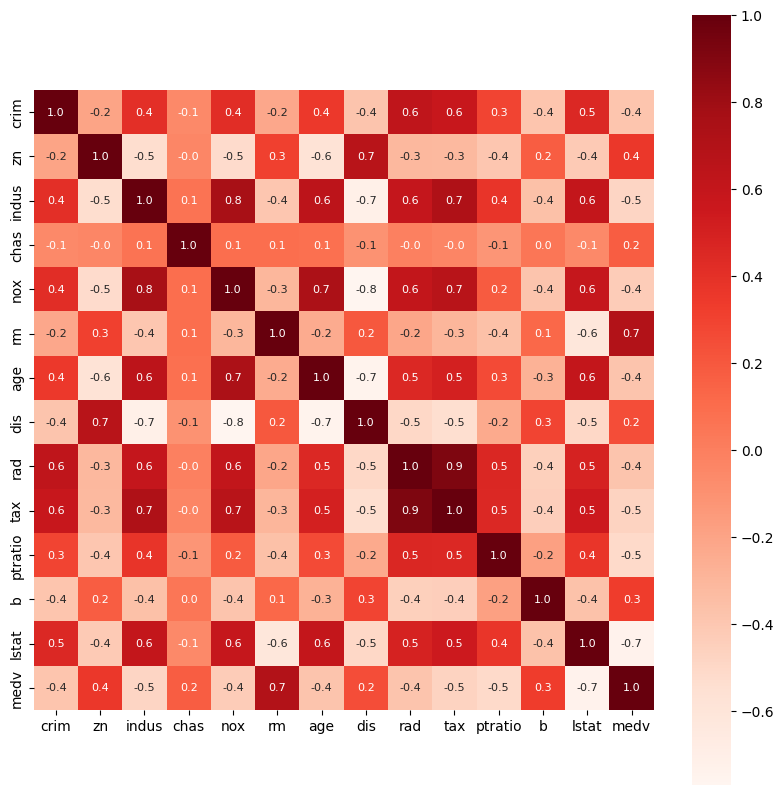

In [15]:
#constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size":8},cmap='Reds')

now we split the data into training and testing dataset


importing the library

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop(['medv'],axis=1)
y = df['medv']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
#checking the shapes
print(X_train.shape , X_test.shape)

(404, 13) (102, 13)


now we train the model 


to train it we are using XGBoost Regressor

In [26]:
#loading the model
model=XGBRegressor()

In [28]:
model.fit(X_train , y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


now the model is fitted , we can now make prediction 

Evaluation

In [29]:
#prediction accuracy for training data
df_prediction= model.predict(X_train)
print(df_prediction)

[23.114786  20.991802  20.102772  34.686405  13.889966  13.50908
 21.998613  15.200822  10.899967  22.673662  13.784466   5.5997276
 29.799892  49.998978  34.89508   20.603088  23.378973  19.216482
 32.70595   19.60561   26.989954   8.404433  45.999386  21.695728
 27.075636  19.34733   19.297901  24.814804  22.609327  31.724865
 18.505766   8.694836  17.406515  23.699665  13.304497  10.494304
 12.660826  24.998928  19.693281  14.885039  24.209171  24.992125
 14.906643  17.015781  15.595363  12.691417  24.504877  15.005457
 50.004223  17.54174   21.182016  32.00974   15.597706  22.898912
 19.302542  18.71413   23.301388  37.20696   30.095572  33.10776
 20.99071   49.99511   13.39284    5.0152636 16.501806   8.396905
 28.68056   19.498354  20.593115  45.409267  39.80977   33.405617
 19.807083  33.398743  25.277815  49.995125  12.540555  17.437073
 18.603241  22.612633  50.00789   23.789232  23.309439  23.09976
 41.70135   16.116299  31.596655  36.090157   7.002144  20.387321
 19.993427  

Error Evaluation


In [31]:
#R squared error
s1 = metrics.r2_score(y_train, df_prediction)
#mean absolute error
s2= metrics.mean_absolute_error(y_train, df_prediction)

In [33]:
print("r squared error :", s1)
print("mean absolute error :", s2)

r squared error : 0.9999966325788185
mean absolute error : 0.011629054806019995


prediction on test data

In [34]:
df_prediction= model.predict(X_test)

In [35]:
#accuracy on test data 
#R squared error
s1 = metrics.r2_score(y_test, df_prediction)
#mean absolute error
s2= metrics.mean_absolute_error(y_test, df_prediction)
print("r squared error :", s1)
print("mean absolute error :", s2)

r squared error : 0.8870752449670208
mean absolute error : 2.1487043006747375


visualizing the predicted outcome to the known outcome using scatter plot

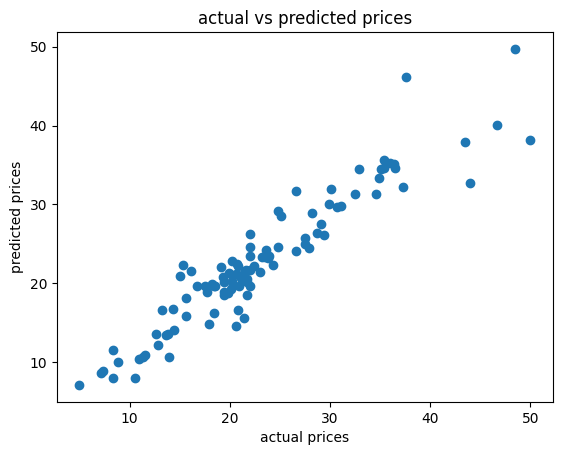

In [38]:
plt.scatter(y_test, df_prediction)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted prices")
plt.show()